Original Data Shape: (178, 13)

First 5 rows of Original Data:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   


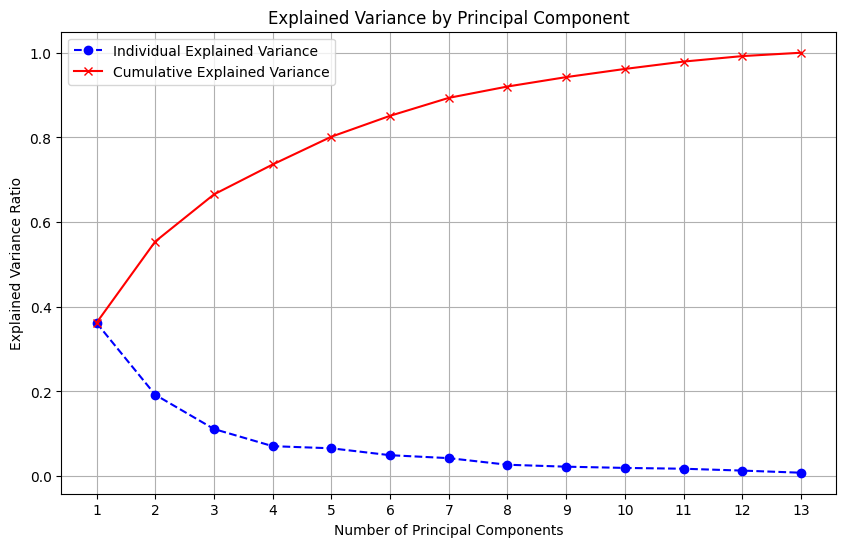


First 5 rows of 2 Principal Components (for visualization):
        PC1       PC2  WineClass
0  3.316751  1.443463          0
1  2.209465 -0.333393          0
2  2.516740  1.031151          0
3  3.757066  2.756372          0
4  1.008908  0.869831          0


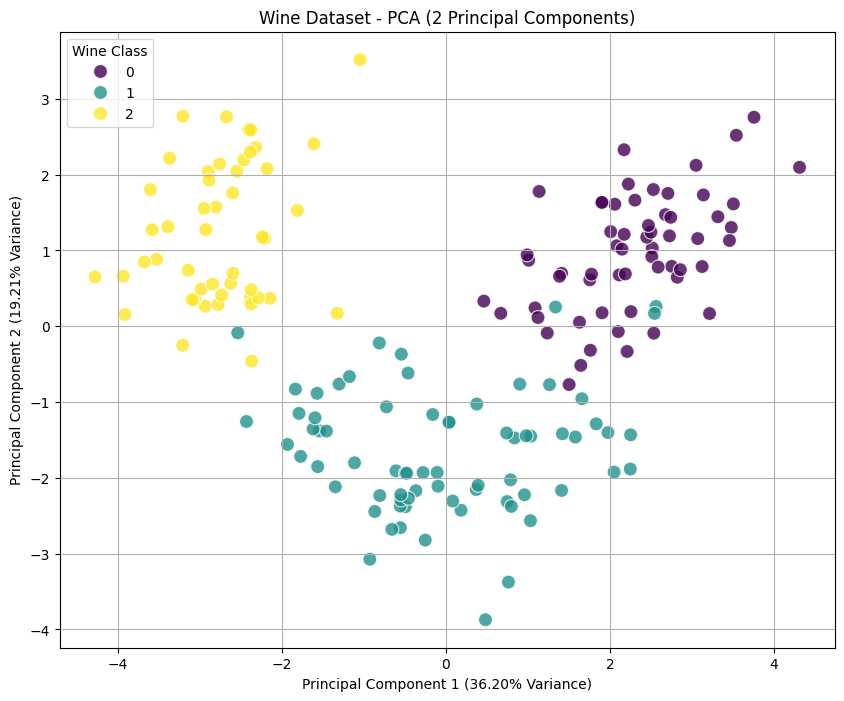


Accuracy of Random Forest Classifier on 2 PCA Components: 0.9815
Accuracy of Random Forest Classifier on Original Scaled Data: 1.0000


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Dataset
# We'll use the built-in wine dataset from sklearn for convenience
from sklearn.datasets import load_wine
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='WineClass') # The target variable (wine type)

print("Original Data Shape:", X.shape)
print("\nFirst 5 rows of Original Data:")
print(X.head())

# 2. Standardize the Data
# PCA is sensitive to the scale of the features.
# It's crucial to scale your data before applying PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of Scaled Data:")
print(X_scaled_df.head())

# 3. Apply PCA
# We'll start by keeping all components to understand the explained variance
pca = PCA()
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for the principal components
# We name them PC1, PC2, etc.
pc_df = pd.DataFrame(data = principal_components,
                     columns = [f'PC{i+1}' for i in range(X.shape[1])])

print("\nFirst 5 rows of Principal Components:")
print(pc_df.head())

# 4. Analyze Explained Variance
# This tells us how much information each principal component retains
explained_variance_ratio = pca.explained_variance_ratio_
print("\nExplained Variance Ratio for each Principal Component:")
print(explained_variance_ratio)

# Cumulative explained variance
cumulative_explained_variance = explained_variance_ratio.cumsum()
print("\nCumulative Explained Variance:")
print(cumulative_explained_variance)

# Plotting explained variance to decide on the number of components
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='blue', label='Individual Explained Variance')
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='x', linestyle='-', color='red', label='Cumulative Explained Variance')
plt.title('Explained Variance by Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.legend()
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

# Interpretation:
# From the plot and cumulative sum, we can see that:
# PC1 explains ~36% of the variance.
# PC1 + PC2 explain ~55% of the variance.
# PC1 + PC2 + PC3 explain ~66% of the variance.
# If we want to capture, say, 95% of the variance, we'd need to look at the cumulative sum.
# It looks like 9 components capture over 95% of the variance.

# 5. Apply PCA with a reduced number of components (e.g., 2 for visualization)
pca_2_components = PCA(n_components=2)
principal_components_2d = pca_2_components.fit_transform(X_scaled)

pc_2d_df = pd.DataFrame(data = principal_components_2d,
                        columns = ['PC1', 'PC2'])

# Add the target variable for visualization
pc_2d_df['WineClass'] = y

print("\nFirst 5 rows of 2 Principal Components (for visualization):")
print(pc_2d_df.head())

# 6. Visualize the Data in 2D Principal Component Space
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='WineClass', data=pc_2d_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('Wine Dataset - PCA (2 Principal Components)')
plt.xlabel(f'Principal Component 1 ({pca_2_components.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca_2_components.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True)
plt.legend(title='Wine Class')
plt.show()

# Conclusion from Visualization:
# We can clearly see that the different wine classes are well-separated in the 2D PCA space,
# even though we reduced the dimensionality from 13 features to just 2!
# This demonstrates PCA's effectiveness for visualization and separation.

# 7. Using PCA Transformed Data for Machine Learning (Example)
# Now, you can use `principal_components_2d` (or `principal_components` with desired n_components)
# as input for a classification algorithm, for instance:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split the 2D PCA data for training and testing
X_train_pca, X_test_pca, y_train, y_test = train_test_split(principal_components_2d, y, test_size=0.3, random_state=42)

# Train a classifier on the reduced data
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train_pca, y_train)
y_pred = classifier.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of Random Forest Classifier on 2 PCA Components: {accuracy:.4f}")

# For comparison, train on original data (if you have time)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
classifier_orig = RandomForestClassifier(random_state=42)
classifier_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = classifier_orig.predict(X_test_orig)
accuracy_orig = accuracy_score(y_test_orig, y_pred_orig)
print(f"Accuracy of Random Forest Classifier on Original Scaled Data: {accuracy_orig:.4f}")

# In this specific case, 2 components might not achieve the same accuracy as 13 components,
# but it illustrates the concept of using PCA output as model input.
# Often, for very high-dimensional data, PCA can lead to similar or even better performance
# due to noise reduction and simplifying the model.



Loadings (Coefficients) for the first 2 Principal Components:
      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1  0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2  0.483652    0.224931  0.316069          -0.010591   0.299634   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
PC1       0.394661    0.422934             -0.298533         0.313429   
PC2       0.065040   -0.003360              0.028779         0.039302   

     color_intensity       hue  od280/od315_of_diluted_wines   proline  
PC1        -0.088617  0.296715                      0.376167  0.286752  
PC2         0.529996 -0.279235                     -0.164496  0.364903  


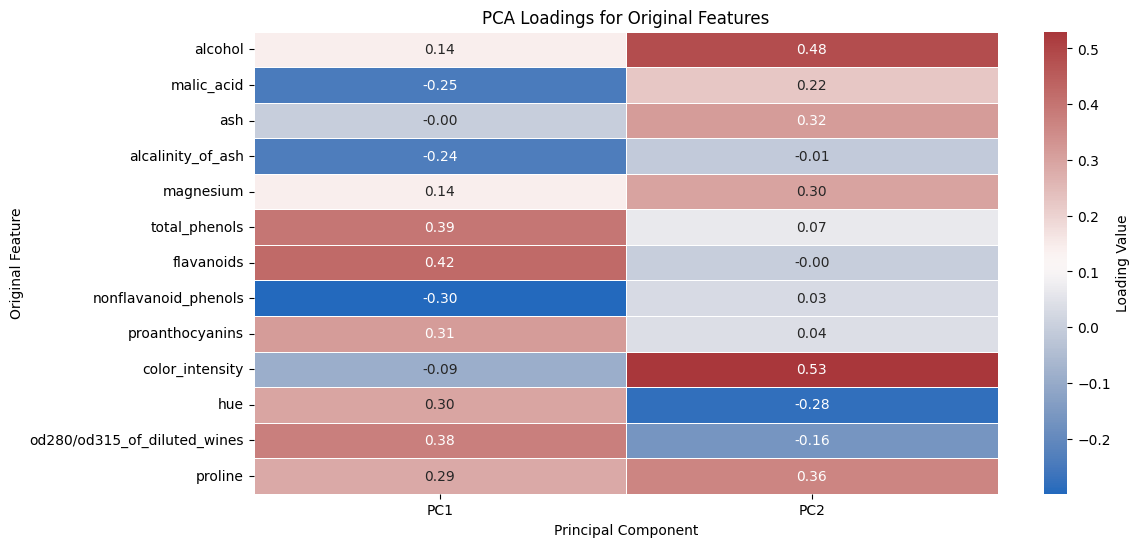

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

# Load the dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Apply PCA (e.g., for 2 components)
pca_2_components = PCA(n_components=2)
principal_components_2d = pca_2_components.fit_transform(X_scaled)

# Get the loadings (components)
# pca_2_components.components_ gives an array where rows are PCs and columns are original features
loadings_df = pd.DataFrame(pca_2_components.components_,
                           columns=X.columns,
                           index=['PC1', 'PC2'])

print("\nLoadings (Coefficients) for the first 2 Principal Components:")
print(loadings_df)

# Visualize Loadings (Optional, but very helpful)
plt.figure(figsize=(12, 6))
sns.heatmap(loadings_df.T, cmap='vlag', annot=True, fmt=".2f",
            linewidths=.5, cbar_kws={'label': 'Loading Value'})
plt.title('PCA Loadings for Original Features')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.show()

# Interpretation based on the output:
# - Look at PC1 row: Which features have the largest absolute values? What are their signs?
# - Look at PC2 row: Which features have the largest absolute values? What are their signs?

# Example interpretation based on typical wine dataset PC1 loadings:
# PC1 often has high positive loadings for 'proline', 'total_phenols', 'flavanoids',
# and high negative loadings for 'malic_acid', 'ash', 'alcalinity_of_ash'.
# This suggests PC1 might represent 'Wine Body/Complexity' or 'Quality' where higher values mean richer wines.

# Example interpretation based on typical wine dataset PC2 loadings:
# PC2 often has high positive loadings for 'color_intensity', 'hue',
# and high negative loadings for 'alcohol', 'nonflavanoid_phenols'.
# This could relate to 'Color Profile' or 'Ripeness'.